<a href="https://www.kaggle.com/code/nicapotato/indian-startup-funding-analysis?scriptVersionId=340388609" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Guided Numeric Exploration — Indian Startup Funding
_Industry, stage, city, and investor patterns in a 300-row funding table (2018–2026)_

***

**Programming Language:** Python in the Jupyter Notebook Environment

**Dataset:** [gautampatil9898/indian-startup-funding-dataset](https://www.kaggle.com/datasets/gautampatil9898/indian-startup-funding-dataset)

**Style counterpart:** [Guided Numeric and Text Exploration — E-Commerce](https://www.kaggle.com/code/nicapotato/guided-numeric-and-text-exploration-e-commerce)

**Code Navigation:** <br>
In the code, text after hashtags (`#`) are supportive explanations, not executed as code.

***


# Tables of Content:

**1. [Introduction](#Introduction)** <br>
**2. [Setup and Data Peek](#Setup)** <br>
**3. [Univariate Landscape](#Univariate)** <br>
**4. [Funding by Industry, Stage, Geography](#Funding)** <br>
**5. [Investors and Company Size](#Investors)** <br>
**6. [What It Means — Working Synthesis](#Synthesis)** <br>

# **1. Introduction:** <a id="Introduction"></a> <br>
A compact Indian startup funding table (**300 rows**, 2018–2026) with industry, city/state, stage, lead investor, funding amount, and employee count. Names look practice-table styled (`Startup_001`…).

**Critical caveat:** `Status` is **100% `Active`** in this file — it cannot be an outcome or filter. All analysis treats `Funding_Amount_USD` (and size) as the interesting continuous signals.


# **2. Setup and Data Peek:** <a id="Setup"></a>


In [1]:
# General
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Scientific / modeling helpers
from IPython.display import display
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

import kagglehub

# Set Plot Theme (same family as the e-commerce guided notebook)
sns.set_palette([
    "#30a2da",
    "#fc4f30",
    "#e5ae38",
    "#6d904f",
    "#8b8b8b",
])
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Wide table inspection in Jupyter cell outputs
pd.set_option("display.max_columns", 999)
pd.set_option("display.width", 220)


**Code Explanation and Reasoning:** <br>
These packages fall into three buckets: *General*, *Visualization*, and *Scientific / modeling helpers*.

`pandas` / `numpy` hold the table; `matplotlib` / `seaborn` do the graphics; `scipy` and `sklearn` support light associational checks (correlations, RandomForest importances), not a production model. `kagglehub` resolves files both on Kaggle (`/kaggle/input/...`) and locally.

The five-color palette matches the guided e-commerce notebook so sequential plots feel like one continuous exploration.


In [2]:
# Read and Peak at Data
CSV_BASENAME = "Indian_Startup_Funding_Dataset.csv"
KAGGLE_SLUG = "gautampatil9898/indian-startup-funding-dataset"
EXPECTED_COLS = [
    "Startup_ID", "Startup_Name", "Industry", "City", "State", "Funding_Year",
    "Funding_Stage", "Lead_Investor", "Funding_Amount_USD", "Employees", "Status",
]


def resolve_csv_path() -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        hits = list(kaggle_root.rglob(CSV_BASENAME))
        assert hits, f"{CSV_BASENAME} not under /kaggle/input"
        return hits[0]
    local_data = Path("data") / CSV_BASENAME
    if local_data.exists():
        return local_data
    root = Path(kagglehub.dataset_download(KAGGLE_SLUG))
    hits = list(root.rglob(CSV_BASENAME))
    assert hits, f"expected {CSV_BASENAME} under {root}"
    return hits[0]


csv_path = resolve_csv_path()
print("CSV:", csv_path)
df = pd.read_csv(csv_path, low_memory=False)
missing = set(EXPECTED_COLS) - set(df.columns)
assert not missing, f"missing columns: {sorted(missing)}"
assert len(df) == 300, f"expected 300 rows, got {len(df)}"
assert df.isnull().sum().sum() == 0, "unexpected nulls"
status_vals = sorted(df["Status"].unique().tolist())
assert status_vals == ["Active"], f"Status should be constant Active, got {status_vals}"
print("Status values (constant — not usable as outcome):", status_vals)

unique_count = [[c, df[c].nunique(dropna=False), int(df[c].isnull().sum())] for c in df.columns]
print("Missing Values:", df.isnull().sum().sum())
print("Dataframe Dimension: {} Rows, {} Columns".format(*df.shape))
print("Years:", sorted(df["Funding_Year"].unique().tolist()))
print("Funding_Amount_USD mean/median:", round(df["Funding_Amount_USD"].mean()), round(df["Funding_Amount_USD"].median()))


CSV: /kaggle/input/datasets/gautampatil9898/indian-startup-funding-dataset/Indian_Startup_Funding_Dataset.csv
Status values (constant — not usable as outcome): ['Active']
Missing Values: 0
Dataframe Dimension: 300 Rows, 11 Columns
Years: [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
Funding_Amount_USD mean/median: 24749000 24700000


**Code Explanation and Reasoning:** <br>
Schema and n=300 are asserted. The constant-`Status` check fails loud if a future version adds exits — until then, Status is documented noise, not a label.


In [3]:
df.sample(5, random_state=7)


,Startup_ID,Startup_Name,Industry,City,State,Funding_Year,Funding_Stage,Lead_Investor,Funding_Amount_USD,Employees,Status
254,255,Startup_255,Cybersecurity,Chennai,Tamil Nadu,2026,Seed,Blume Ventures,31200000,313,Active
57,58,Startup_058,E-commerce,Chennai,Tamil Nadu,2018,Series C,Accel,44400000,136,Active
150,151,Startup_151,FinTech,Pune,Maharashtra,2019,Pre-Series A,Blume Ventures,30500000,142,Active
66,67,Startup_067,AI,Delhi,Delhi,2021,Pre-Series A,Accel,44300000,191,Active
114,115,Startup_115,Logistics,Ahmedabad,Gujarat,2021,Seed,Peak XV,48400000,68,Active


In [4]:
display(pd.DataFrame(unique_count, columns=["Column", "Unique", "Null"]))
df[["Funding_Amount_USD", "Employees", "Funding_Year"]].describe().T.round(2)


,Column,Unique,Null
0,Startup_ID,300,0
1,Startup_Name,300,0
2,Industry,10,0
3,City,10,0
4,State,9,0
5,Funding_Year,9,0
6,Funding_Stage,5,0
7,Lead_Investor,8,0
8,Funding_Amount_USD,235,0
9,Employees,226,0


,count,mean,std,min,25%,50%,75%,max
Funding_Amount_USD,300.0,24749000.00,14713521.83,100000.0,11900000.0,24700000.0,38000000.00,49500000.0
Employees,300.0,250.03,144.00,6.0,129.0,240.0,375.75,500.0
Funding_Year,300.0,2021.98,2.59,2018.0,2020.0,2022.0,2024.00,2026.0


**Interpretation** <br>
Every row is an Active company with a funding round. Variation lives in industry, geography, stage, investor, dollars, and headcount — not survival status.


# **3. Univariate Landscape:** <a id="Univariate"></a>


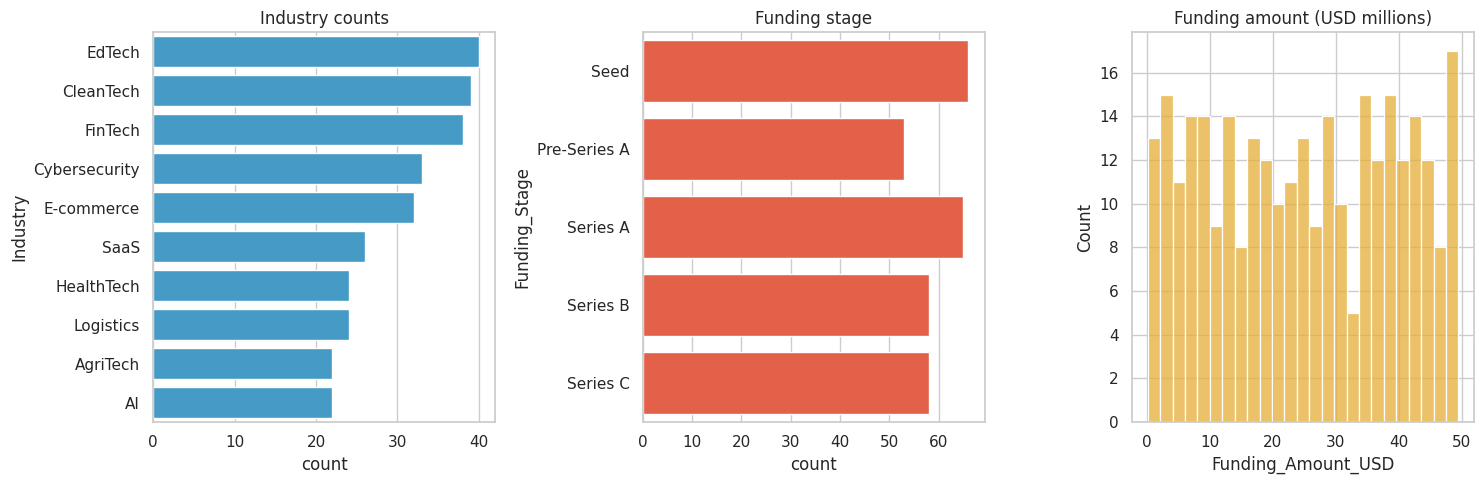

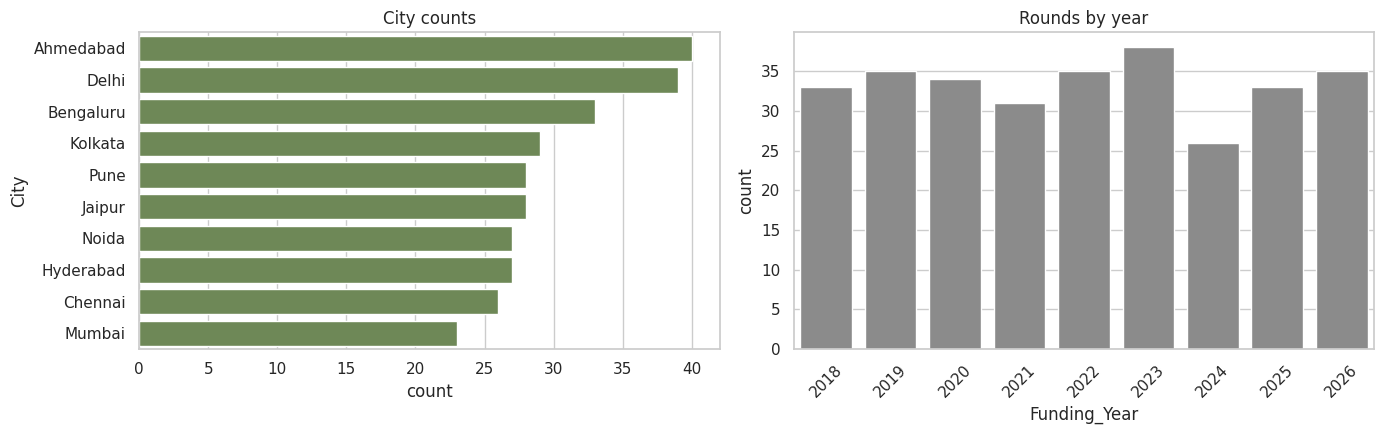

In [5]:
f, ax = plt.subplots(1, 3, figsize=(15, 5))
sns.countplot(data=df, y="Industry", order=df["Industry"].value_counts().index, ax=ax[0], color="#30a2da")
ax[0].set_title("Industry counts")
stage_order = ["Seed", "Pre-Series A", "Series A", "Series B", "Series C"]
stage_order = [s for s in stage_order if s in set(df["Funding_Stage"])]
sns.countplot(data=df, y="Funding_Stage", order=stage_order, ax=ax[1], color="#fc4f30")
ax[1].set_title("Funding stage")
sns.histplot(df["Funding_Amount_USD"] / 1e6, bins=25, ax=ax[2], color="#e5ae38")
ax[2].set_title("Funding amount (USD millions)")
plt.tight_layout()
plt.show()

f, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sns.countplot(data=df, y="City", order=df["City"].value_counts().index, ax=ax[0], color="#6d904f")
ax[0].set_title("City counts")
sns.countplot(data=df, x="Funding_Year", ax=ax[1], color="#8b8b8b")
ax[1].set_title("Rounds by year")
ax[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


**How to Interpret:** <br>
Industry and city bars show where the table over-samples. Stage mix and dollar histogram describe the capital ladder available for later stratified compares.


# **4. Funding by Industry, Stage, Geography:** <a id="Funding"></a>


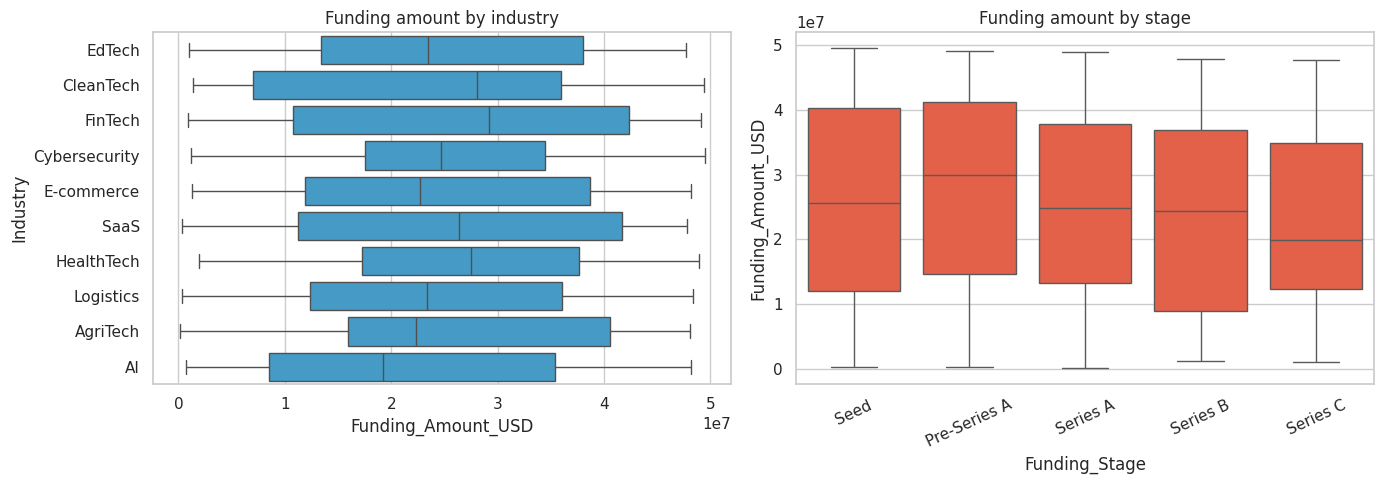

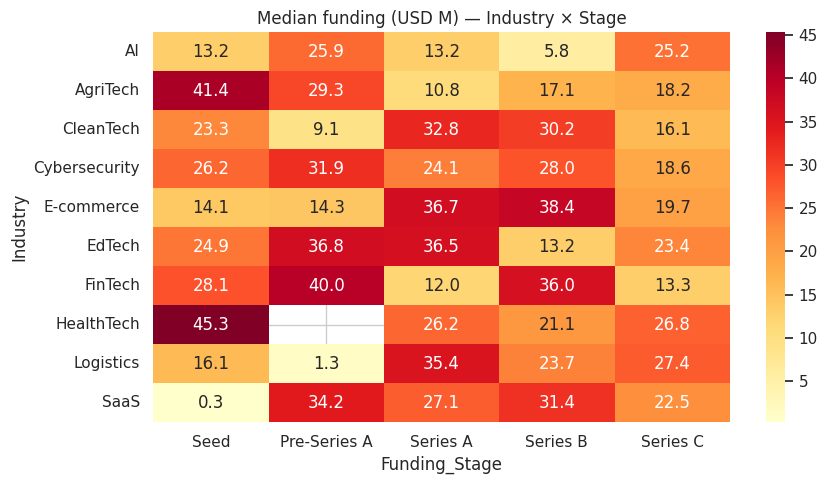

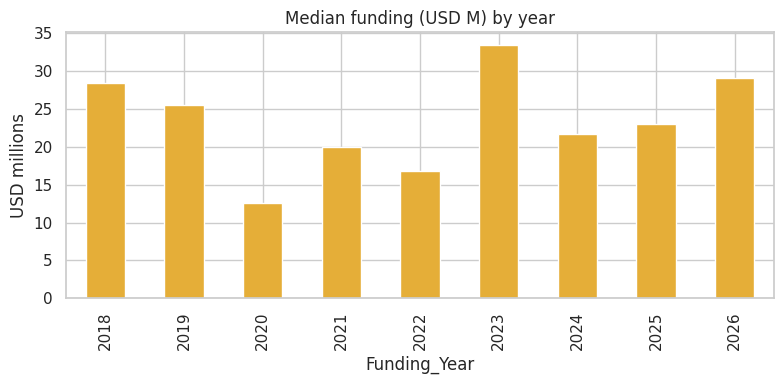

In [6]:
f, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(
    data=df, y="Industry", x="Funding_Amount_USD",
    order=df["Industry"].value_counts().index, ax=ax[0], color="#30a2da",
)
ax[0].set_title("Funding amount by industry")
sns.boxplot(data=df, x="Funding_Stage", y="Funding_Amount_USD", order=stage_order, ax=ax[1], color="#fc4f30")
ax[1].set_title("Funding amount by stage")
ax[1].tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

med = df.groupby(["Industry", "Funding_Stage"])["Funding_Amount_USD"].median().unstack()
med = med.reindex(columns=[c for c in stage_order if c in med.columns])
f, ax = plt.subplots(figsize=(9, 5))
sns.heatmap((med / 1e6), annot=True, fmt=".1f", cmap="YlOrRd", ax=ax)
ax.set_title("Median funding (USD M) — Industry × Stage")
plt.tight_layout()
plt.show()

year_med = df.groupby("Funding_Year")["Funding_Amount_USD"].median() / 1e6
f, ax = plt.subplots(figsize=(8, 4))
year_med.plot(kind="bar", ax=ax, color="#e5ae38")
ax.set_title("Median funding (USD M) by year")
ax.set_ylabel("USD millions")
plt.tight_layout()
plt.show()


**How to Interpret:** <br>
Stage boxes should rise if later rounds raise more. Industry × stage medians show which sectors the table pays up at the same stage. Year bars are noisy at n=300 — read as descriptive only.


# **5. Investors and Company Size:** <a id="Investors"></a>


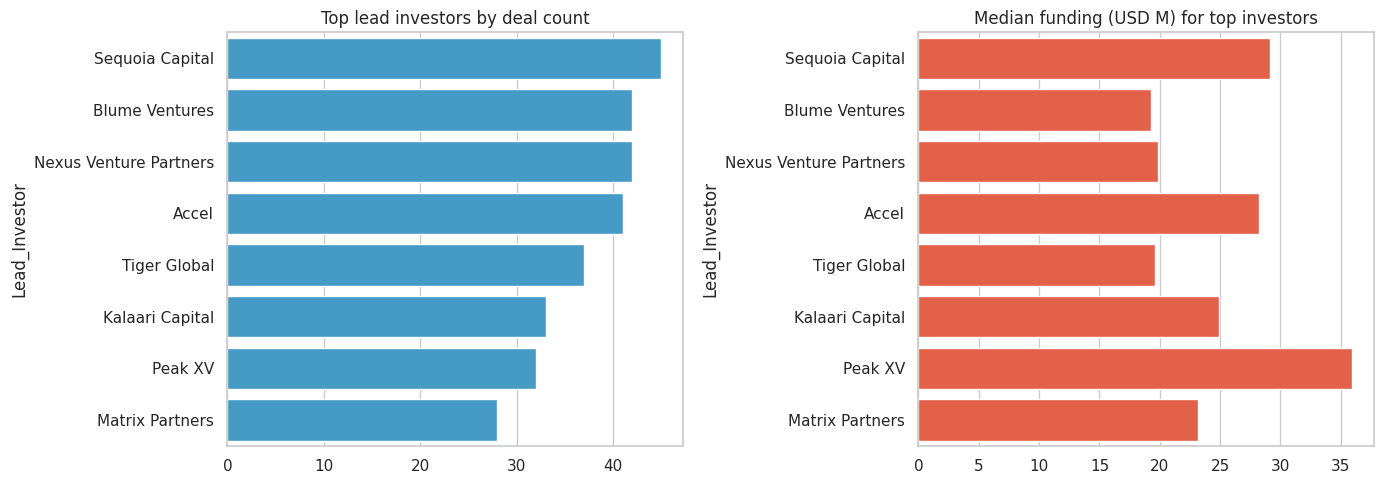

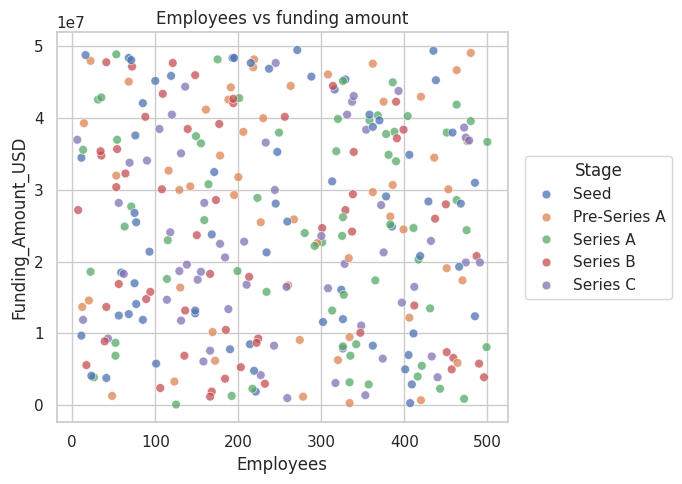

Pearson r(Employees, Funding_Amount_USD): -0.041


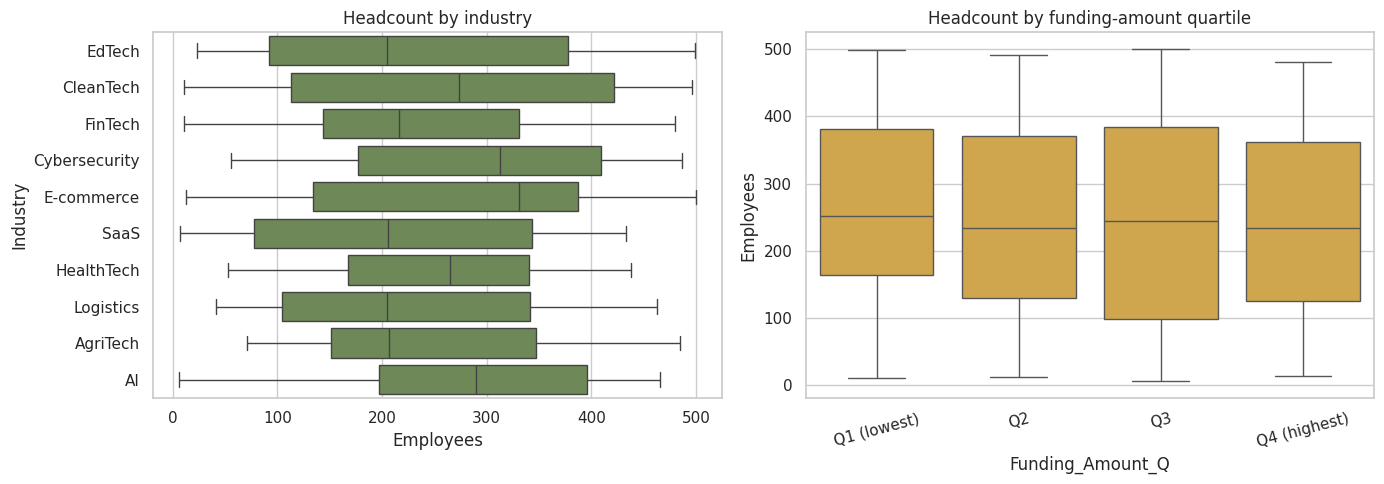

Headcount by industry:


,n,median,mean
Industry,,,
EdTech,40,204.5,231.7
CleanTech,39,274.0,262.2
FinTech,38,216.0,228.7
Cybersecurity,33,313.0,290.0
E-commerce,32,331.0,271.5
SaaS,26,205.5,212.8
HealthTech,24,264.5,258.2
Logistics,24,204.5,228.5
AgriTech,22,207.0,244.1


Headcount by funding-amount quartile:


,n,median,mean
Funding_Amount_Q,,,
Q1 (lowest),76,251.0,260.0
Q2,75,234.0,248.5
Q3,75,244.0,246.7
Q4 (highest),74,233.5,244.8


In [7]:
top_inv = df["Lead_Investor"].value_counts().head(10)
f, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=top_inv.values, y=top_inv.index, ax=ax[0], color="#30a2da")
ax[0].set_title("Top lead investors by deal count")
inv_amt = (
    df.groupby("Lead_Investor")["Funding_Amount_USD"]
    .median()
    .loc[top_inv.index] / 1e6
)
sns.barplot(x=inv_amt.values, y=inv_amt.index, ax=ax[1], color="#fc4f30")
ax[1].set_title("Median funding (USD M) for top investors")
plt.tight_layout()
plt.show()

f, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    data=df, x="Employees", y="Funding_Amount_USD",
    hue="Funding_Stage", hue_order=stage_order, ax=ax, alpha=0.75, s=40,
)
ax.set_title("Employees vs funding amount")
ax.legend(title="Stage", bbox_to_anchor=(1.02, 0.5), loc="center left")
plt.tight_layout()
plt.show()
print("Pearson r(Employees, Funding_Amount_USD):", round(df["Employees"].corr(df["Funding_Amount_USD"]), 3))

# Headcount size by industry, then by funding-amount quartile
funding_q = pd.qcut(
    df["Funding_Amount_USD"],
    4,
    labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"],
)
f, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(
    data=df, y="Industry", x="Employees",
    order=df["Industry"].value_counts().index, ax=ax[0], color="#6d904f",
)
ax[0].set_title("Headcount by industry")
sns.boxplot(
    data=df.assign(Funding_Amount_Q=funding_q),
    x="Funding_Amount_Q", y="Employees",
    ax=ax[1], color="#e5ae38",
)
ax[1].set_title("Headcount by funding-amount quartile")
ax[1].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

hc_by_ind = (
    df.groupby("Industry")["Employees"]
    .agg(n="count", median="median", mean="mean")
    .reindex(df["Industry"].value_counts().index)
    .round(1)
)
print("Headcount by industry:")
display(hc_by_ind)

hc_by_fund = (
    df.assign(Funding_Amount_Q=funding_q)
    .groupby("Funding_Amount_Q", observed=True)["Employees"]
    .agg(n="count", median="median", mean="mean")
    .round(1)
)
print("Headcount by funding-amount quartile:")
display(hc_by_fund)


**How to Interpret:** <br>
Investor counts show who originates rounds in this table; median check size may differ from count rank. Employee–funding scatter asks whether larger teams associate with larger rounds after stage hue.

Headcount boxes by industry show which sectors run leaner vs heavier teams at similar deal counts. Funding-amount quartiles ask the same question on capital: if bigger rounds hire more people, medians should step up Q1→Q4 — flat boxes mean dollars and headcount are weakly coupled in this table.


# **6. What It Means — Working Synthesis:** <a id="Synthesis"></a>

**What the table is:** <br>
A small Indian funding practice set with constant Status=Active.

**Working takeaways:** <br>
- Never use `Status` as a label here.
- Stage and industry structure funding amounts; geography and investors add secondary strata.
- Headcount varies by industry; funding-amount quartile is a second cut on whether capital tracks team size.
- n=300 limits any year-trend claim.

**Open follow-ups:** <br>
- Investor specialization by industry (crosstab heatmaps).
- Log-funding regression on stage + employees + city tier.
